# Text Classification

## What is Text Classification?
Assign predefined categories to text documents. One of the most common NLP tasks.

**Examples:**
- Spam detection (spam / not spam)
- Sentiment analysis (positive / negative / neutral)
- Topic classification (politics, sports, technology...)
- Intent detection (book_flight, check_weather...)
- Language identification
- Content moderation

---

## 1. Traditional Methods

### TF-IDF + Logistic Regression / SVM
- Extract TF-IDF features from text
- Train classical ML classifier
- Fast, interpretable, strong baseline

### Naive Bayes for Text
$$P(c|d) \propto P(c) \prod_{i=1}^{n} P(w_i|c)$$

---

## 2. Deep Learning Approaches

### 2.1 TextCNN (Kim, 2014)
Apply convolutions over word embeddings with multiple filter sizes to capture n-gram features:

$$c_i = f(w \cdot x_{i:i+h-1} + b)$$

Max-over-time pooling: $\hat{c} = \max\{c_1, c_2, ..., c_{n-h+1}\}$

### 2.2 BiLSTM with Attention
BiLSTM captures sequential context. Attention weights important tokens:

$$e_t = v^T \tanh(W h_t + b)$$
$$\alpha_t = \frac{\exp(e_t)}{\sum_k \exp(e_k)}$$
$$c = \sum_t \alpha_t h_t$$

---

## 3. BERT for Classification

Fine-tune pretrained BERT. The `[CLS]` token's final hidden state is used as the sentence representation:

$$P(c|x) = \text{softmax}(W \cdot h_{[CLS]})$$

Cross-entropy loss:
$$L = -\sum_c y_c \log \hat{y}_c$$

---

## 4. Zero-Shot Classification

Classify without any labeled training data by using NLI (Natural Language Inference).

Frame as: *"This text is about {label}."* → entailment / contradiction?

---

## 5. SetFit: Few-Shot Learning

Fine-tune sentence transformers with very few labeled examples (8-64) using contrastive learning:
1. Fine-tune embedding model on labeled pairs
2. Train classification head on embedded examples

---

## 6. Data Augmentation for Text

When labeled data is scarce:
- **Synonym Replacement**: Replace $n$ random words with synonyms
- **Random Insertion**: Insert random synonym of a random word
- **Random Swap**: Swap two random words
- **Random Deletion**: Delete each word with probability $p$
- **Back-Translation**: Translate to another language and back
- **Paraphrasing with LLMs**: Generate variations using GPT

EDA augmentation improves performance especially for small datasets ($n < 500$).

---

## 7. Evaluation Metrics

$$\text{Precision} = \frac{TP}{TP + FP}, \quad \text{Recall} = \frac{TP}{TP + FN}$$

$$F_1 = \frac{2 \cdot P \cdot R}{P + R}$$

For multi-class:
- **Macro**: Average over all classes equally
- **Micro**: Aggregate all TP/FP/FN globally
- **Weighted**: Weight by class support

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Sample dataset (movie reviews)
texts = [
    "This movie was absolutely fantastic! Great acting and storyline.",
    "Terrible film. Complete waste of time. Very boring.",
    "Amazing performances by all actors. Highly recommended!",
    "Worst movie I've ever seen. Plot made no sense.",
    "Brilliant direction and stunning visuals. A masterpiece.",
    "Dull, predictable, and poorly written. Skip it.",
    "Outstanding! This film moved me to tears. Perfect.",
    "Awful acting, terrible script. Don't watch this.",
    "Incredible story with beautiful cinematography.",
    "Boring and slow. Characters were flat and uninteresting.",
    "One of the best films of the year. Must see!",
    "Disappointing and overrated. Expected much better.",
    "Heartwarming and funny. The whole family enjoyed it.",
    "Poor special effects and weak storyline.",
    "Captivating from start to finish. Excellent!",
    "Not worth watching. Complete disappointment."
]
labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.25, random_state=42, stratify=labels
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 12, Test: 4


In [2]:
# ============================================================
# TRADITIONAL METHODS
# ============================================================
models = {
    'TF-IDF + Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=5000)),
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    'TF-IDF + LinearSVC': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=5000)),
        ('clf', LinearSVC(max_iter=1000))
    ]),
    'TF-IDF + Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=5000)),
        ('clf', MultinomialNB())
    ]),
}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    acc = pipeline.score(X_test, y_test)
    print(f"{name}: Accuracy = {acc:.4f}")

TF-IDF + Logistic Regression: Accuracy = 0.2500
TF-IDF + LinearSVC: Accuracy = 0.2500
TF-IDF + Naive Bayes: Accuracy = 0.0000


Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
    Positive       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4



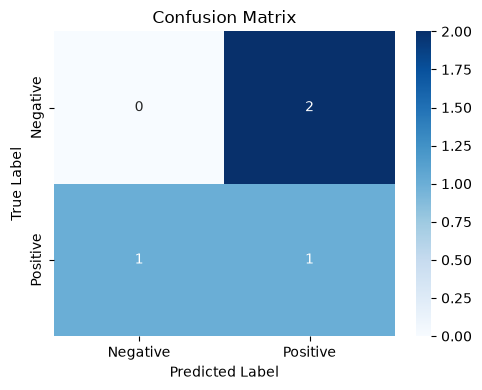

In [3]:
# Detailed evaluation
best_model = models['TF-IDF + Logistic Regression']
y_pred = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
ax.set_title('Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# TextCNN FROM SCRATCH IN PYTORCH
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, num_filters=100,
                 filter_sizes=[2, 3, 4], dropout=0.5):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Multiple filter sizes to capture different n-gram features
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (fs, embed_dim)) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x).unsqueeze(1)  # (batch, 1, seq_len, embed_dim)
        
        # Apply convolutions with different filter sizes
        pooled = []
        for conv in self.convs:
            c = F.relu(conv(x)).squeeze(3)   # (batch, num_filters, seq_len-fs+1)
            c = F.max_pool1d(c, c.size(2)).squeeze(2)  # Max-over-time pooling
            pooled.append(c)
        
        x = torch.cat(pooled, dim=1)  # (batch, num_filters * len(filter_sizes))
        x = self.dropout(x)
        return self.fc(x)

# Initialize
model = TextCNN(vocab_size=10000, embed_dim=100, num_classes=2,
                num_filters=128, filter_sizes=[2, 3, 4, 5])
print("TextCNN Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TextCNN Architecture:
TextCNN(
  (embedding): Embedding(10000, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv2d(1, 128, kernel_size=(2, 100), stride=(1, 1))
    (1): Conv2d(1, 128, kernel_size=(3, 100), stride=(1, 1))
    (2): Conv2d(1, 128, kernel_size=(4, 100), stride=(1, 1))
    (3): Conv2d(1, 128, kernel_size=(5, 100), stride=(1, 1))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=2, bias=True)
)

Total parameters: 1,180,738


In [5]:
# ============================================================
# BERT FOR CLASSIFICATION with Hugging Face
# ============================================================
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    from transformers import TrainingArguments, Trainer
    import torch
    
    print("BERT Fine-tuning for Sentiment Classification")
    print("=" * 50)
    
    # Load tokenizer and model
    model_name = "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # Tokenize texts
    def tokenize(texts, max_length=128):
        return tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )
    
    sample = tokenize(["This movie is great!", "Terrible film."])
    print(f"Input IDs shape: {sample['input_ids'].shape}")
    print(f"Attention mask shape: {sample['attention_mask'].shape}")
    
    # Model for sequence classification
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    print(f"\nModel: {model_name}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print()
    print("Fine-tuning code (requires more data):")
    print("""
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        warmup_steps=500,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        load_best_model_at_end=True,
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=compute_metrics
    )
    trainer.train()
    """)
    
except ImportError:
    print("Install: pip install transformers torch")

BERT Fine-tuning for Sentiment Classification


Input IDs shape: torch.Size([2, 7])
Attention mask shape: torch.Size([2, 7])


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model: distilbert-base-uncased
Parameters: 66,955,010

Fine-tuning code (requires more data):

    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        warmup_steps=500,
        weight_decay=0.01,
        evaluation_strategy='epoch',
        load_best_model_at_end=True,
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=compute_metrics
    )
    trainer.train()
    


In [6]:
# ============================================================
# ZERO-SHOT CLASSIFICATION
# ============================================================
try:
    from transformers import pipeline
    
    classifier = pipeline("zero-shot-classification",
                          model="facebook/bart-large-mnli")
    
    texts_to_classify = [
        "The president signed the new healthcare bill today.",
        "The team scored three goals in the final match.",
        "New AI model achieves state-of-the-art on benchmarks."
    ]
    candidate_labels = ["politics", "sports", "technology", "entertainment"]
    
    for text in texts_to_classify:
        result = classifier(text, candidate_labels)
        print(f"Text: {text[:50]}...")
        print(f"  Predicted: {result['labels'][0]} ({result['scores'][0]:.3f})")
        print()
        
except ImportError:
    print("Install: pip install transformers")
except Exception as e:
    print(f"Note: Requires model download. {e}")

Text: The president signed the new healthcare bill today...
  Predicted: politics (0.714)



Text: The team scored three goals in the final match....
  Predicted: sports (0.807)



Text: New AI model achieves state-of-the-art on benchmar...
  Predicted: technology (0.985)



In [7]:
# ============================================================
# DATA AUGMENTATION (EDA - Easy Data Augmentation)
# ============================================================
import random
from nltk.corpus import wordnet
import nltk
nltk.download('wordnet', quiet=True)

def get_synonyms(word):
    """Get synonyms from WordNet"""
    synonyms = []
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace('_', ' ')
            if synonym != word:
                synonyms.append(synonym)
    return list(set(synonyms))

def synonym_replacement(text, n=2):
    """Replace n random words with synonyms"""
    words = text.split()
    new_words = words.copy()
    random_word_list = [w for w in words if get_synonyms(w.lower())]
    random.shuffle(random_word_list)
    num_replaced = 0
    for word in random_word_list:
        synonyms = get_synonyms(word.lower())
        if synonyms:
            synonym = random.choice(synonyms)
            new_words = [synonym if w == word else w for w in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return ' '.join(new_words)

def random_deletion(text, p=0.1):
    """Randomly delete words with probability p"""
    words = text.split()
    if len(words) == 1:
        return text
    new_words = [w for w in words if random.random() > p]
    return ' '.join(new_words) if new_words else random.choice(words)

def random_swap(text, n=1):
    """Randomly swap n pairs of words"""
    words = text.split()
    for _ in range(n):
        if len(words) >= 2:
            i, j = random.sample(range(len(words)), 2)
            words[i], words[j] = words[j], words[i]
    return ' '.join(words)

original = "This movie was absolutely fantastic with great acting"
print(f"Original:            {original}")
print(f"Synonym replacement: {synonym_replacement(original, n=2)}")
print(f"Random deletion:     {random_deletion(original, p=0.2)}")
print(f"Random swap:         {random_swap(original, n=2)}")

Original:            This movie was absolutely fantastic with great acting


Synonym replacement: This movie Washington absolutely fantastic with great playacting
Random deletion:     This was absolutely fantastic with acting
Random swap:         This movie was absolutely with fantastic acting great


## Additional Learning Resources

### Papers
- [TextCNN: Convolutional Neural Networks for Sentence Classification](https://arxiv.org/abs/1408.5882) Kim, 2014
- [BERT: Pre-training of Deep Bidirectional Transformers](https://arxiv.org/abs/1810.04805) Devlin et al., 2018
- [EDA: Easy Data Augmentation Techniques](https://arxiv.org/abs/1901.11196) Wei & Zou, 2019
- [SetFit: Efficient Few-Shot Learning](https://arxiv.org/abs/2209.11055) Tunstall et al., 2022
- [Zero-Shot Text Classification via NLI](https://arxiv.org/abs/1909.00161) Yin et al., 2019

### Tutorials
- [Hugging Face Text Classification Guide](https://huggingface.co/docs/transformers/tasks/sequence_classification)
- [Hugging Face NLP Course Chapter 3](https://huggingface.co/learn/nlp-course/chapter3/1)
- [Stanford CS224n Assignment 5](https://web.stanford.edu/class/cs224n/)

### Libraries
- [scikit-learn Text Classification](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html)
- [SetFit Library](https://github.com/huggingface/setfit)
- [nlpaug: Text Augmentation](https://github.com/makcedward/nlpaug)